# 🌸 Iris Dataset — Exploratory Data Analysis

**Objective:** Understand the structure, distributions, and relationships between features of the classic Iris dataset to prepare for classification modeling.

**Dataset:** 150 samples, 3 species (*setosa*, *versicolor*, *virginica*), 4 numeric features.

**Notebook structure:**
1. Setup & Imports
2. Data Loading
3. Data Overview
4. Statistical Summary
5. Missing Values
6. Class Distribution
7. Feature Analysis by Species
8. Visualizations (pairplot, boxplots, correlation)
9. Insights & Conclusions

In [1]:
# 1. Setup & Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

print("Setup complete.")

Setup complete.


In [2]:
# 2. Data Loading
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target_names[iris.target]

print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(10)

Dataset shape: 150 rows × 5 columns


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [3]:
# 3. Data Overview
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Info ===")
df.info()
print("\n=== Shape ===")
print(df.shape)

=== Data Types ===
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object

=== Info ===
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB

=== Shape ===
(150, 5)


In [4]:
# 4. Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


In [5]:
# 5. Missing Values Check
missing = df.isnull().sum()
print("=== Missing Values ===")
print(missing[missing > 0] if missing.any() else "No missing values found. ✅")

# Duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

=== Missing Values ===
No missing values found. ✅

Duplicate rows: 1


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


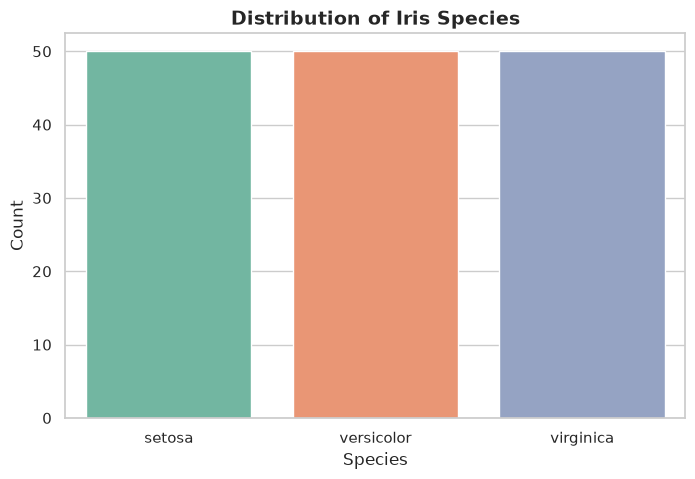

In [11]:
# 6. Class Distribution
class_counts = df["species"].value_counts()
print(class_counts)

# Bar plot
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="species", hue="species", palette="Set2", legend=False)
plt.title("Distribution of Iris Species", fontsize=14, fontweight="bold")
plt.xlabel("Species")
plt.ylabel("Count")
plt.show()

In [7]:
# 7. Feature Analysis by Species
feature_cols = iris.feature_names
df.groupby("species")[feature_cols].mean().T

species,setosa,versicolor,virginica
sepal length (cm),5.006,5.936,6.588
sepal width (cm),3.428,2.770,2.974
petal length (cm),1.462,4.260,5.552
petal width (cm),0.246,1.326,2.026


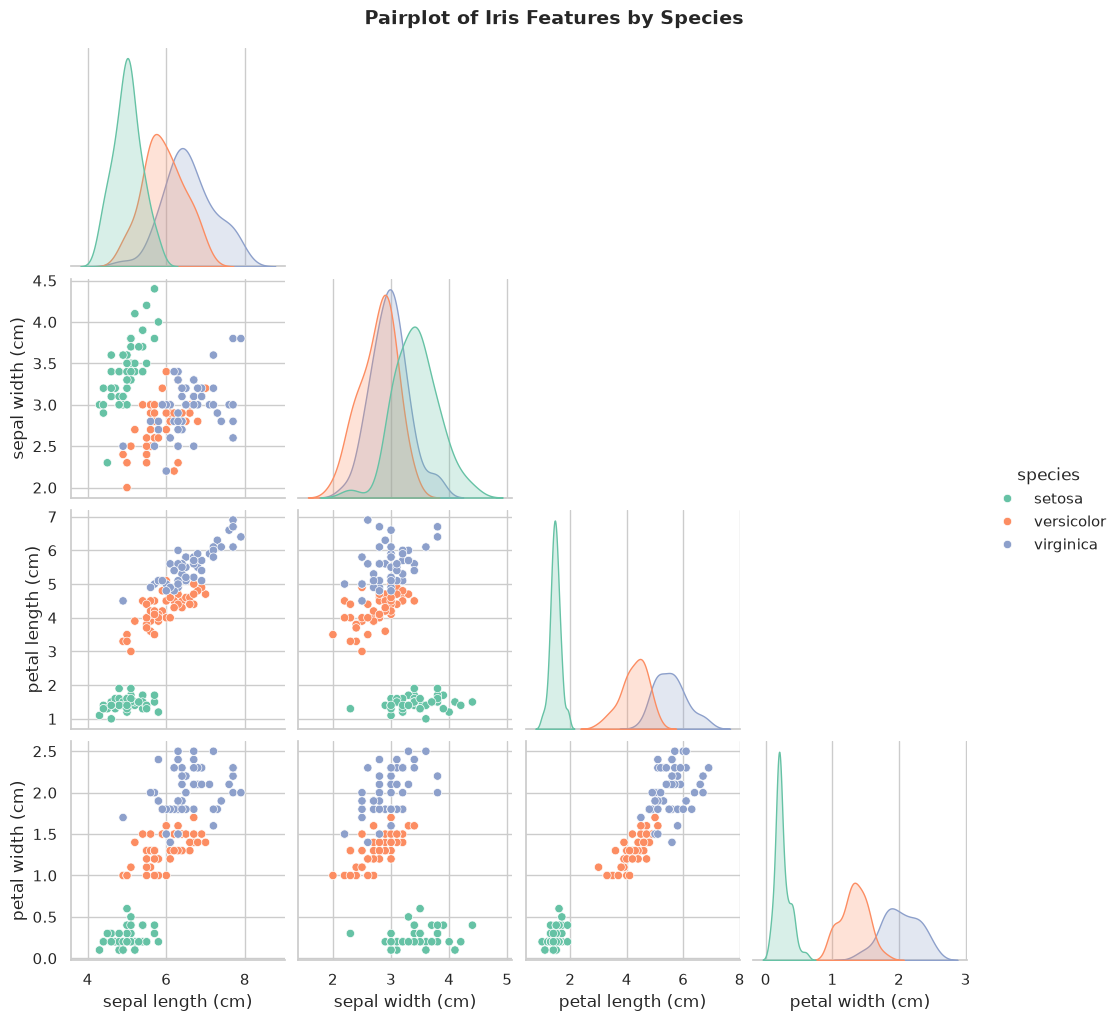

In [8]:
# 8a. Pairplot — Feature Relationships by Species
sns.pairplot(df, hue="species", diag_kind="kde", corner=True, palette="Set2")
plt.suptitle("Pairplot of Iris Features by Species", y=1.02, fontsize=14, fontweight="bold")
plt.show()

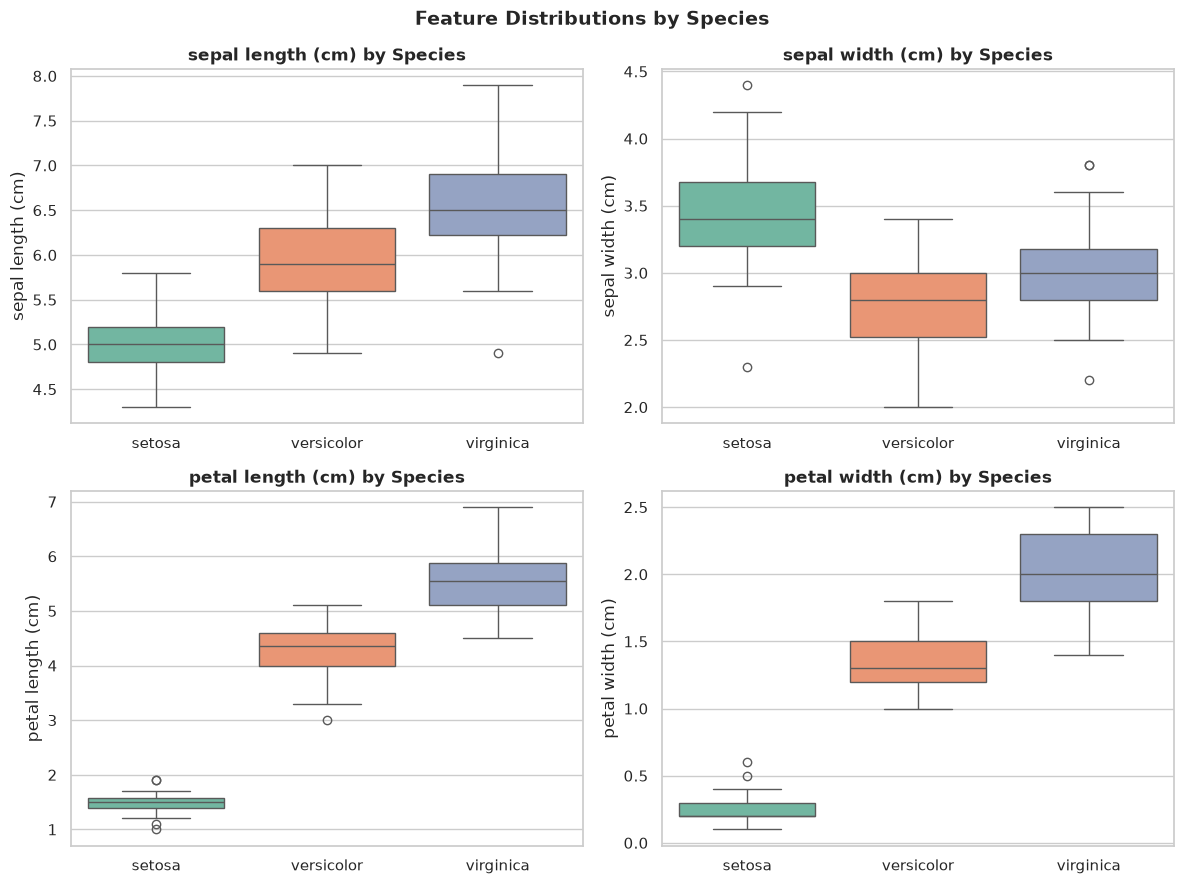

In [12]:
# 8b. Boxplots — Feature Distribution per Species
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.flatten(), feature_cols):
    sns.boxplot(data=df, x="species", y=col, hue="species", ax=ax, palette="Set2", legend=False)
    ax.set_title(f"{col} by Species", fontweight="bold")
    ax.set_xlabel("")
plt.suptitle("Feature Distributions by Species", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

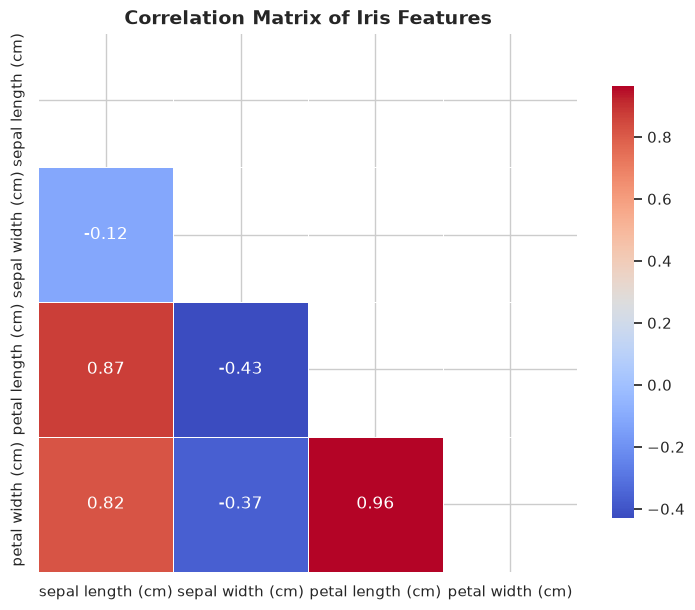

In [10]:
# 8c. Correlation Heatmap
plt.figure(figsize=(9, 7))
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", mask=mask,
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix of Iris Features", fontsize=14, fontweight="bold")
plt.show()

## 📌 Insights & Conclusions

1. **Balanced dataset** — 50 samples per species, no missing values, no significant duplicates.
2. **Setosa is clearly separable** — its petal length/width are much smaller and non-overlapping with the other two species.
3. **Versicolor vs Virginica overlap** — these two species overlap in sepal features but are more separable using *petal* features.
4. **Strong correlations** — petal length & petal width are highly correlated (≈0.96), making them the most discriminative features.
5. **Modeling implication** — a simple linear model (e.g., Logistic Regression) or tree-based model should achieve near-perfect accuracy, especially using petal features.